<a href="https://colab.research.google.com/github/MohtadiIbtesum/cse422_project/blob/main/attrition_project_finalv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
from google.colab import files
uploaded = files.upload()

Saving 4.csv to 4 (1).csv
Saving 4_test.csv to 4_test (1).csv


In [35]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.utils import resample


from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier


import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

# Unsupervised model
from sklearn.cluster import KMeans

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve, silhouette_score,
                              adjusted_rand_score)

sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

import os
OUTPUT_DIR = 'results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
saved_files = []

def save_fig(fig, name):

    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, bbox_inches='tight', dpi=300)
    saved_files.append(path)
    return path

def save_table(df, name):

    path = os.path.join(OUTPUT_DIR, name)
    df.to_csv(path)
    saved_files.append(path)
    return path

In [36]:
df = pd.read_csv('4.csv')
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (1509, 35)


,id,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,36,Travel_Frequently,599,Research & Development,24,3,Medical,1,4,Male,42,3,1,Laboratory Technician,4,Married,2596,5099,1,Y,Yes,13,3,2,80,1,10,2,3,10,0,7,8,0
1,1448,33,Travel_Rarely,530,Sales,3,3,Marketing,1,3,Male,46,3,3,Sales Executive,3,Single,10903,8040,1,Y,Yes,13,3,1,80,0,13,5,3,11,9,6,6,0
2,259,41,Travel_Rarely,1146,Sales,2,3,Medical,1,4,Female,56,3,2,Sales Executive,4,Single,9852,23099,1,Y,No,12,3,4,80,0,10,2,3,10,8,6,0,0
3,340,40,Travel_Rarely,1499,Sales,26,3,Marketing,1,1,Male,76,3,4,Sales Executive,3,Single,13402,11652,4,Y,Yes,20,4,2,80,0,22,3,2,19,7,3,7,0
4,1098,35,Travel_Frequently,806,Research & Development,2,4,Life Sciences,1,4,Female,77,4,1,Research Scientist,2,Married,2996,19121,1,Y,Yes,12,3,4,80,0,6,2,2,6,0,1,3,0


In [37]:
print("Number of data points:", df.shape[0])
print("Number of features (excluding target):", df.shape[1] - 1)
print()
print("Feature dtypes:")
print(df.dtypes.value_counts())
print()
print("Categorical (object/string) columns:")
print(df.select_dtypes(include='object').columns.tolist())
print()
print("Numeric columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

Number of data points: 1509
Number of features (excluding target): 34

Feature dtypes:
int64     27
object     8
Name: count, dtype: int64

Categorical (object/string) columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numeric columns:
['id', 'Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition']


In [38]:
for c in ['EmployeeCount', 'Over18', 'StandardHours']:
    print(c, '-> unique values:', df[c].unique())

EmployeeCount -> unique values: [1]
Over18 -> unique values: ['Y']
StandardHours -> unique values: [80]


Attrition
0    1329
1     180
Name: count, dtype: int64


/tmp/ipykernel_2825/794050766.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette=['#4C72B0', '#DD8452'])


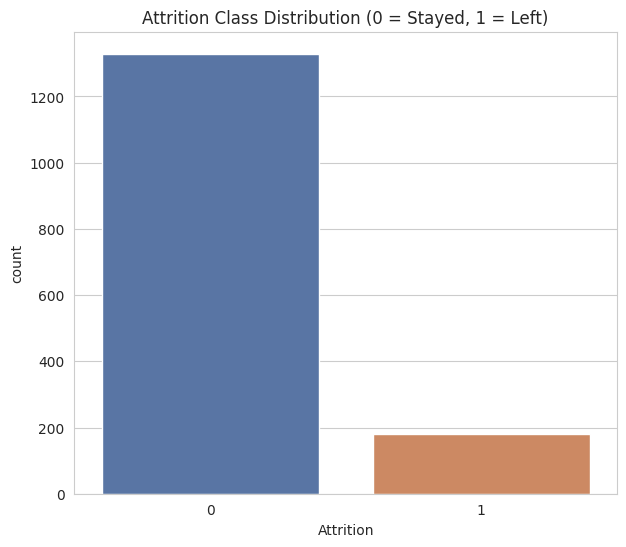

Attrition rate: 11.9% of employees left


In [39]:
attr_counts = df['Attrition'].value_counts()
print(attr_counts)

fig = plt.figure(figsize=(7,6))
sns.countplot(x='Attrition', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Attrition Class Distribution (0 = Stayed, 1 = Left)')
save_fig(fig, '01_attrition_class_distribution.png')
plt.show()
print(f"Attrition rate: {attr_counts[1] / len(df) * 100:.1f}% of employees left")

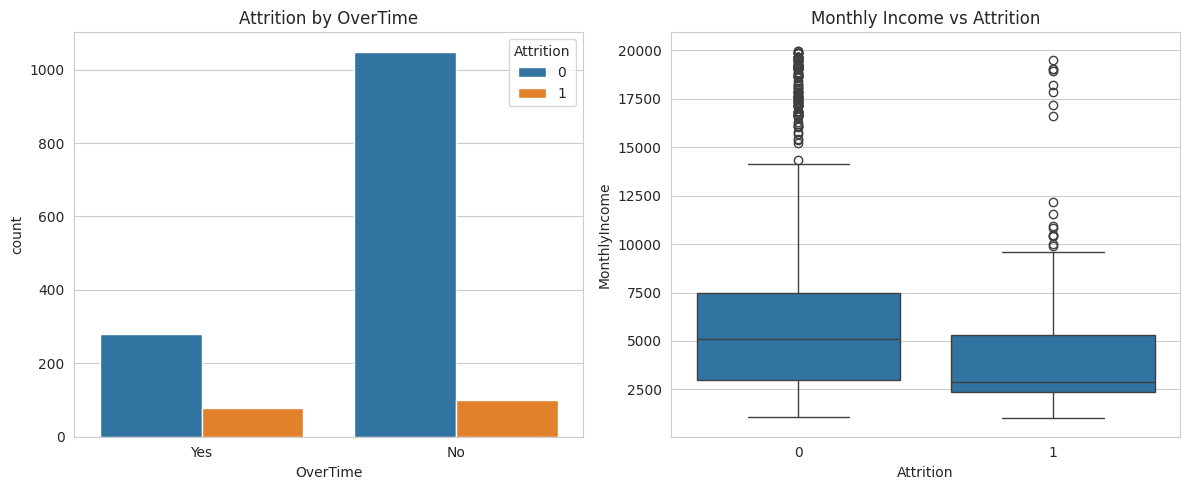

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x='OverTime', hue='Attrition', data=df, ax=axes[0])
axes[0].set_title('Attrition by OverTime')
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[1])
axes[1].set_title('Monthly Income vs Attrition')
plt.tight_layout()
save_fig(fig, '02_overtime_and_income_vs_attrition.png')
plt.show()

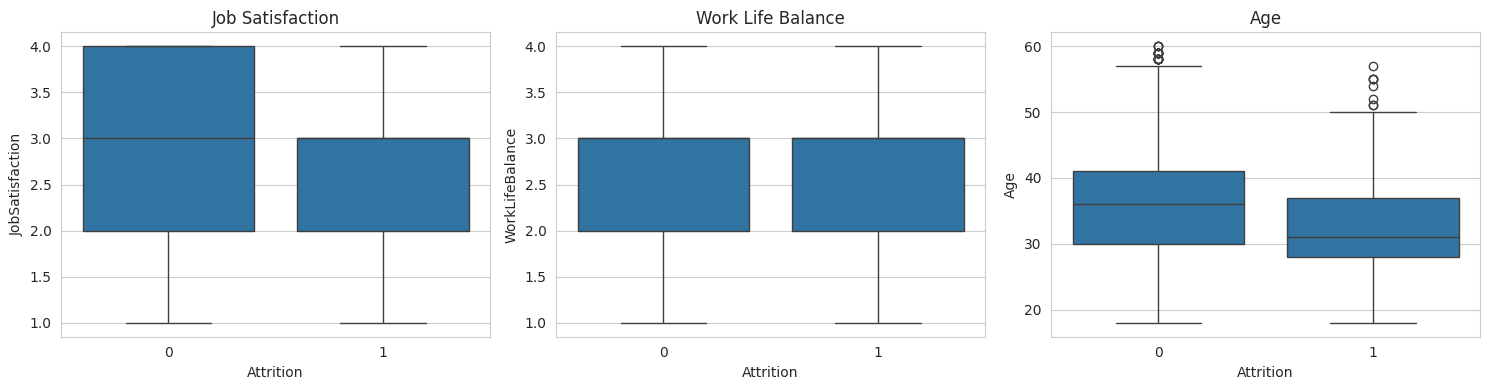

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(x='Attrition', y='JobSatisfaction', data=df, ax=axes[0])
sns.boxplot(x='Attrition', y='WorkLifeBalance', data=df, ax=axes[1])
sns.boxplot(x='Attrition', y='Age', data=df, ax=axes[2])
axes[0].set_title('Job Satisfaction')
axes[1].set_title('Work Life Balance')
axes[2].set_title('Age')
plt.tight_layout()
save_fig(fig, '03_satisfaction_worklife_age_vs_attrition.png')
plt.show()

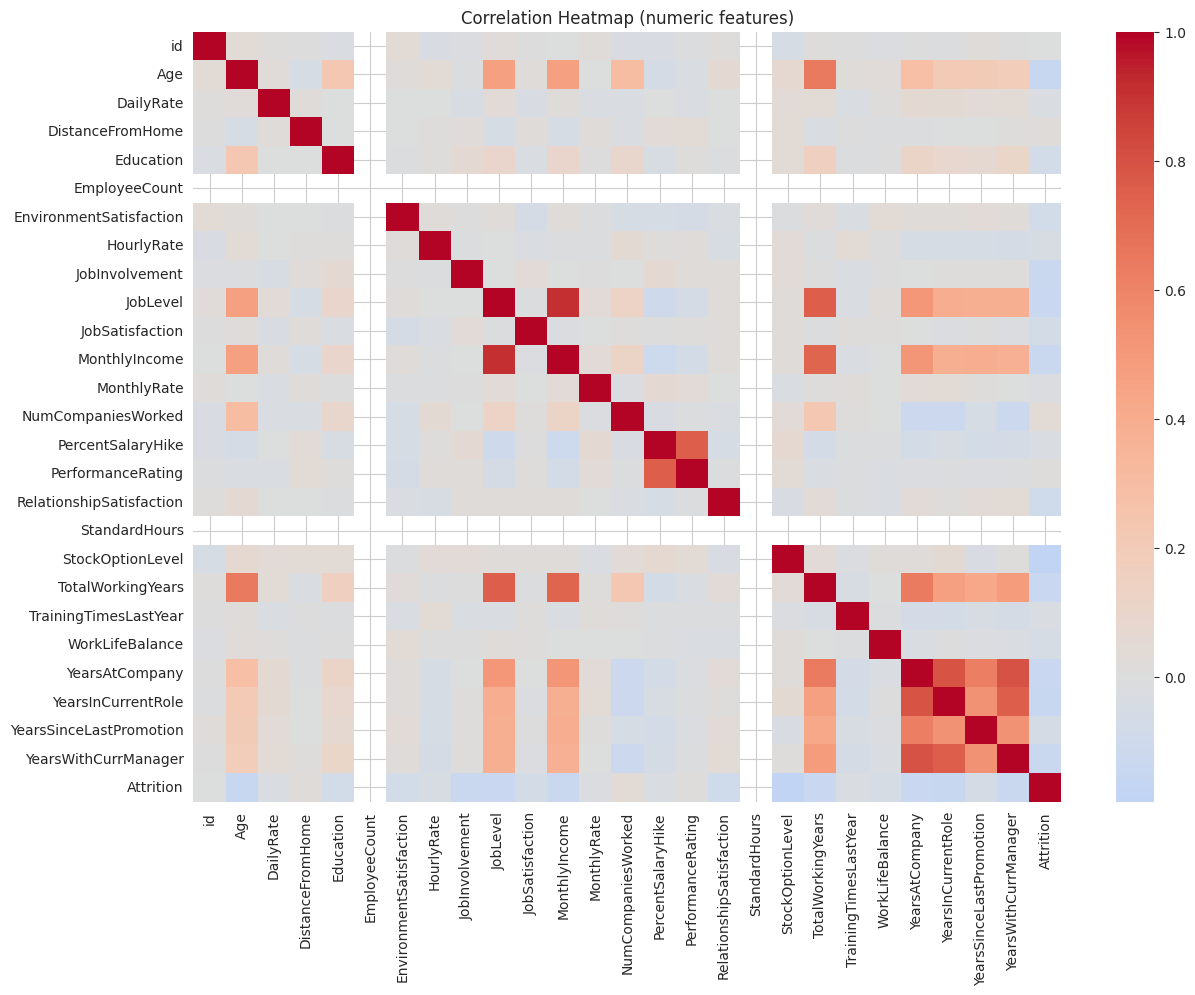

In [42]:
fig = plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap (numeric features)')
save_fig(fig, '04_correlation_heatmap.png')
plt.show()

Department
Sales                     0.144893
Human Resources           0.142857
Research & Development    0.108262
Name: Attrition, dtype: float64


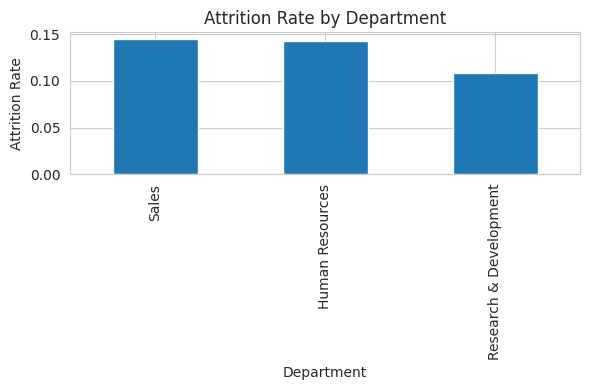

In [43]:
attr_by_dept = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False)
print(attr_by_dept)
fig = plt.figure(figsize=(6,4))
attr_by_dept.plot(kind='bar', title='Attrition Rate by Department')
plt.ylabel('Attrition Rate')
plt.tight_layout()
save_fig(fig, '05_attrition_rate_by_department.png')
plt.show()

In [44]:
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'id']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])
print("Dropped columns:", drop_cols)
print("Remaining shape:", df_clean.shape)

Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'id']
Remaining shape: (1509, 31)


In [45]:
null_counts = df_clean.isnull().sum()
print("Nulls per column:\n", null_counts[null_counts > 0] if null_counts.sum() > 0 else "None")
print("Duplicate rows:", df_clean.duplicated().sum())

before = len(df_clean)
df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()
print(f"Rows dropped: {before - len(df_clean)} -> remaining: {len(df_clean)}")

Nulls per column:
 None
Duplicate rows: 0
Rows dropped: 0 -> remaining: 1509


In [46]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

target_col = 'Attrition'

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

if target_col in cat_cols:
    cat_cols.remove(target_col)
    le = LabelEncoder()
    df_clean[target_col] = le.fit_transform(df_clean[target_col])

df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

display(df_clean.head())

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,36,599,24,3,4,42,3,1,4,2596,5099,1,13,3,2,1,10,2,3,10,0,7,8,0,True,False,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,True
1,33,530,3,3,3,46,3,3,3,10903,8040,1,13,3,1,0,13,5,3,11,9,6,6,0,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,True,True
2,41,1146,2,3,4,56,3,2,4,9852,23099,1,12,3,4,0,10,2,3,10,8,6,0,0,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
3,40,1499,26,3,1,76,3,4,3,13402,11652,4,20,4,2,0,22,3,2,19,7,3,7,0,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,True,True
4,35,806,2,4,4,77,4,1,2,2996,19121,1,12,3,4,0,6,2,2,6,0,1,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True


StockOptionLevel                   -0.193167
MaritalStatus_Single                0.184875
OverTime_Yes                        0.173711
JobRole_Sales Representative        0.157415
Age                                -0.152844
YearsInCurrentRole                 -0.148552
TotalWorkingYears                  -0.144134
YearsAtCompany                     -0.144017
JobLevel                           -0.138736
YearsWithCurrManager               -0.136572
JobInvolvement                     -0.134252
MonthlyIncome                      -0.133891
BusinessTravel_Travel_Frequently    0.111292
JobRole_Manufacturing Director     -0.107753
JobRole_Laboratory Technician       0.101346
Name: Attrition, dtype: float64


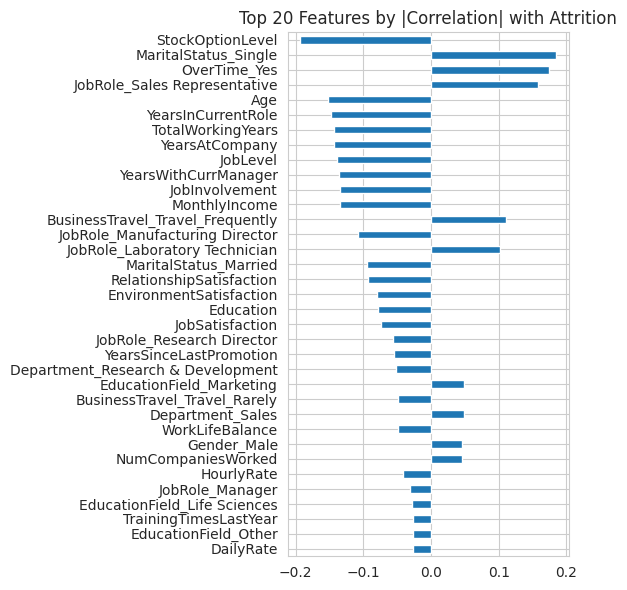

In [47]:
X_full = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

corr_with_target = df_clean.corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)
print(corr_with_target.head(15))

fig = plt.figure(figsize=(6,6))
corr_with_target.head(35).plot(kind='barh')
plt.title('Top 20 Features by |Correlation| with Attrition')
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, '06_top_correlated_features.png')
plt.show()

feature_cols = X_full.columns.tolist()
X = X_full[feature_cols]

In [48]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )


scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)

Train shape: (1207, 44)  Test shape: (302, 44)


In [49]:

lr_unscaled = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_unscaled.fit(X_train, y_train)
f1_unscaled = f1_score(y_test, lr_unscaled.predict(X_test))

lr_scaled = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_scaled.fit(X_train_scaled, y_train)
f1_scaled = f1_score(y_test, lr_scaled.predict(X_test_scaled))

print(f"Logistic Regression F1 — unscaled features: {f1_unscaled:.3f}")
print(f"Logistic Regression F1 — scaled features:   {f1_scaled:.3f}")


Logistic Regression F1 — unscaled features: 0.311
Logistic Regression F1 — scaled features:   0.446


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=42)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

print("New training target distribution after SMOTE:")
print(y_train.value_counts())

New training target distribution after SMOTE:
Attrition
1    1063
0    1063
Name: count, dtype: int64


Components needed to explain 90% of variance: 21 (out of 44 original features)


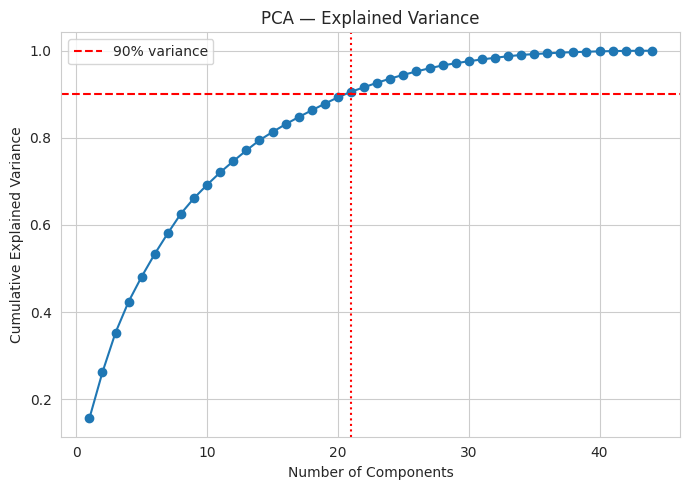

Reduced train shape: (2126, 21)


In [51]:
pca_fs = PCA(random_state=42)
pca_fs.fit(X_train_scaled)

cum_var = np.cumsum(pca_fs.explained_variance_ratio_)
n_components_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Components needed to explain 90% of variance: {n_components_90} (out of {X_train_scaled.shape[1]} original features)")

fig = plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
plt.axvline(n_components_90, color='red', linestyle=':')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Explained Variance')
plt.legend()
plt.tight_layout()
save_fig(fig, '07_pca_explained_variance.png')
plt.show()

pca_final = PCA(n_components=n_components_90, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)
print("Reduced train shape:", X_train_pca.shape)

In [52]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=200,max_depth=7, class_weight="balanced", random_state=42)
}

trained = {}
predictions = {}
probabilities = {}
best_thresh = 0.0

for name, model in models.items():

    model.fit(X_train_scaled, y_train)
    trained[name] = model


    probs = model.predict_proba(X_test_scaled)[:, 1]
    probabilities[name] = probs


    if name == 'Random Forest':
        best_f1 = 0
        best_thresh = 0.5


        for thresh in np.arange(0.1, 0.9, 0.05):
            temp_preds = (probs >= thresh).astype(int)
            temp_f1 = f1_score(y_test, temp_preds)

            if temp_f1 > best_f1:
                best_f1 = temp_f1
                best_thresh = thresh

        print(f"Optimal Threshold for {name}: {best_thresh:.2f}")
        predictions[name] = (probs >= best_thresh).astype(int)

    else:

        predictions[name] = model.predict(X_test_scaled)

    print(f"{name} trained.")


Logistic Regression trained.
Naive Bayes trained.
Optimal Threshold for Random Forest: 0.40
Random Forest trained.


In [53]:
from sklearn.model_selection import cross_val_score

print("5-Fold Cross Validation (Training Data)")
cv_scores = {}


for name in ['Logistic Regression', 'Naive Bayes']:
    model = models[name]
    # Run 5-fold CV on the training data
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores[name] = scores

    print(f"{name}:")
    print(f"  All 5 folds: {np.round(scores, 3)}")
    print(f"  Average Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})\n")

5-Fold Cross Validation (Training Data)
Logistic Regression:
  All 5 folds: [0.791 0.807 0.809 0.819 0.795]
  Average Accuracy: 0.804 (+/- 0.010)

Naive Bayes:
  All 5 folds: [0.676 0.708 0.696 0.701 0.696]
  Average Accuracy: 0.696 (+/- 0.011)



In [54]:

n_features = X_train_scaled.shape[1]
class_weight = {
    0: 1.0,
    1: (y_train == 0).sum() / (y_train == 1).sum()  #
}
print("Class weights used:", class_weight)

nn_model = Sequential([

    Dense(32, activation='relu',input_shape=(n_features,)),
    Dense(16, activation='relu'),
    Dense(1, activation='relu')
])

nn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss=BinaryCrossentropy(),
                  metrics=['accuracy'])

nn_history = nn_model.fit(X_train_scaled, y_train,
                           validation_split=0.15,
                           epochs=80,
                           batch_size=32,
                           class_weight=class_weight,
                           verbose=0)

nn_proba = nn_model.predict(X_test_scaled, verbose=0).ravel()
nn_pred = (nn_proba >= 0.5).astype(int)

trained['Neural Network (Keras)'] = nn_model
predictions['Neural Network (Keras)'] = nn_pred
probabilities['Neural Network (Keras)'] = nn_proba
models['Neural Network (Keras)'] = nn_model

print("Neural Network (Keras) trained.")

Class weights used: {0: 1.0, 1: np.float64(1.0)}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network (Keras) trained.


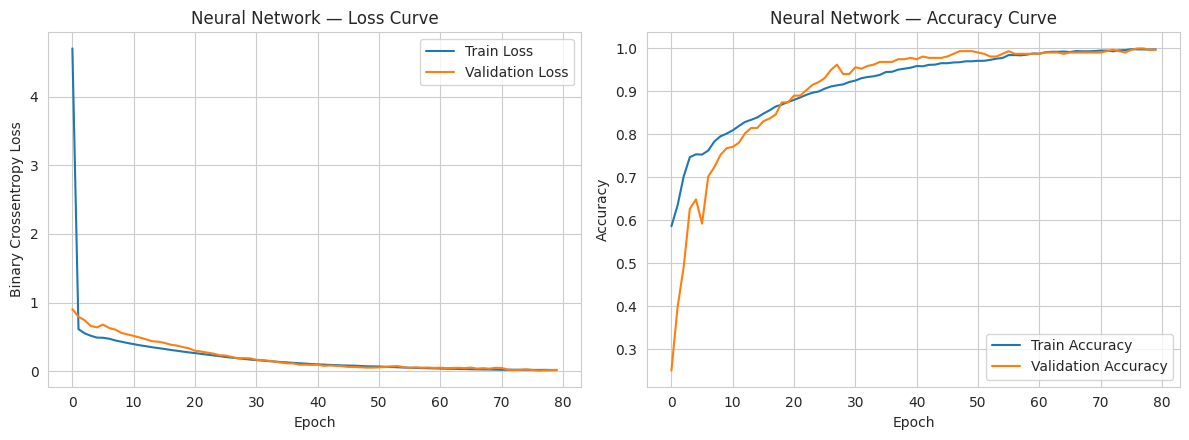

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].plot(nn_history.history['loss'], label='Train Loss')
axes[0].plot(nn_history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Neural Network — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()

axes[1].plot(nn_history.history['accuracy'], label='Train Accuracy')
axes[1].plot(nn_history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Neural Network — Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
save_fig(fig, '08_nn_training_curves.png')
plt.show()

### 5.2 Unsupervised: K-Means Clustering

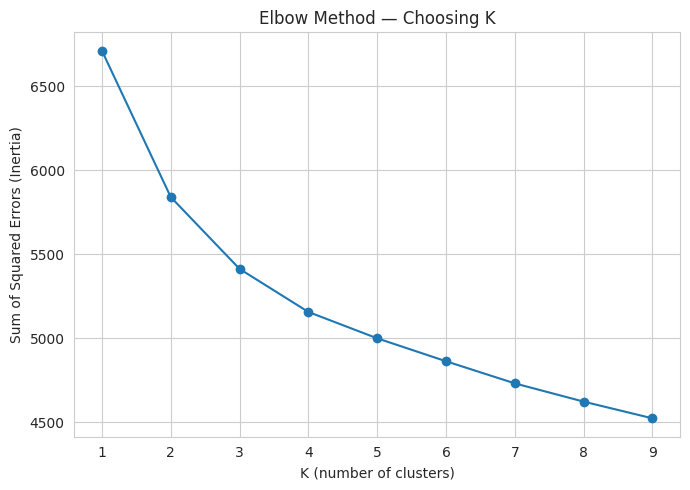

In [56]:
X_all_scaled = scaler.transform(X)

k_range = range(1, 10)
sse = []
for k in k_range:
    km_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_elbow.fit(X_all_scaled)
    sse.append(km_elbow.inertia_)

fig = plt.figure(figsize=(7,5))
plt.plot(list(k_range), sse, marker='o')
plt.xlabel('K (number of clusters)')
plt.ylabel('Sum of Squared Errors (Inertia)')
plt.title('Elbow Method — Choosing K')
plt.tight_layout()
save_fig(fig, '09_elbow_method.png')
plt.show()

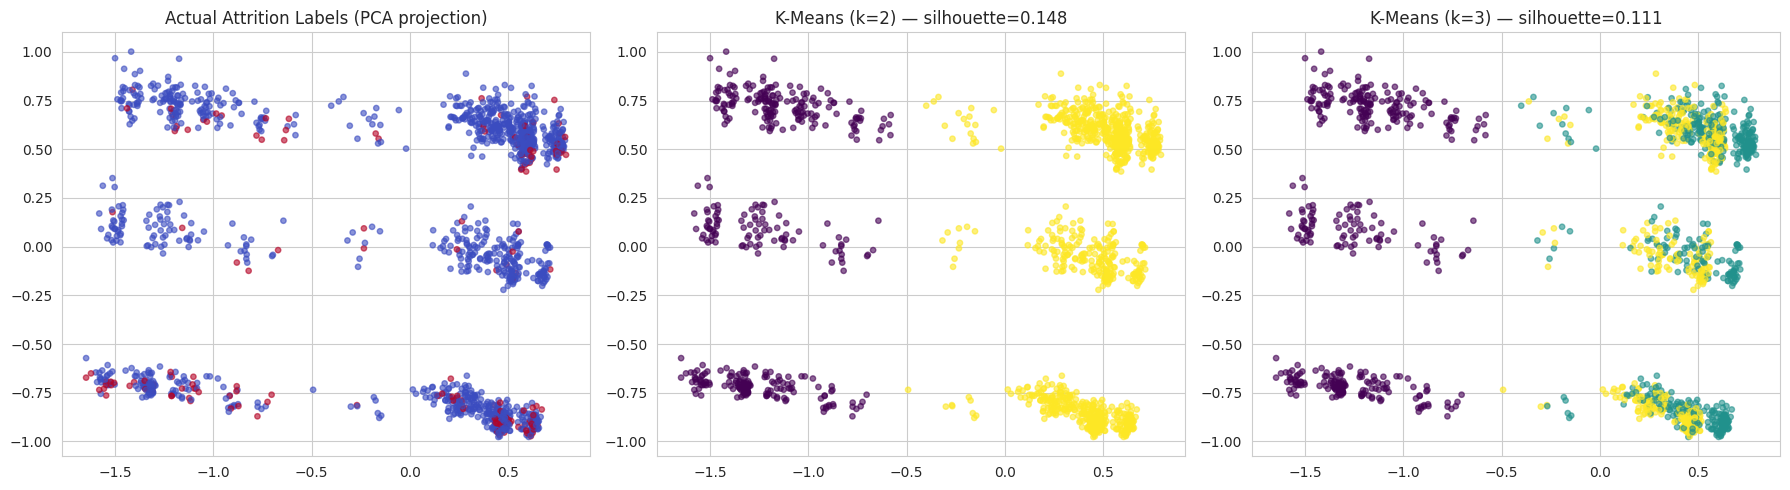

k=2: silhouette score = 0.148
k=3: silhouette score = 0.111


In [57]:
pca_viz = PCA(n_components=2, random_state=42)
X_pca = pca_viz.fit_transform(X_all_scaled)

kmeans_results = {}
fig, axes = plt.subplots(1, 3, figsize=(18,5))


axes[0].scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.6, s=15)
axes[0].set_title('Actual Attrition Labels (PCA projection)')

for i, k in enumerate([2, 3], start=1):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_all_scaled)
    sil = silhouette_score(X_all_scaled, labels)
    kmeans_results[k] = {'model': km, 'labels': labels, 'silhouette': sil}

    axes[i].scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', alpha=0.6, s=15)
    axes[i].set_title(f'K-Means (k={k}) — silhouette={sil:.3f}')

plt.tight_layout()
save_fig(fig, '10_kmeans_clusters.png')
plt.show()

for k, r in kmeans_results.items():
    print(f"k={k}: silhouette score = {r['silhouette']:.3f}")

## 6. Model Evaluation

In [58]:
eval_results = {}

for name in models:

    if name not in predictions:

        y_pred = (probabilities[name] >= 0.5).astype(int)
        predictions[name] = y_pred
    else:
        y_pred = predictions[name]

    y_proba = probabilities[name]
    eval_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(eval_results).T
print(results_df.round(3))
save_table(results_df, 'model_comparison_results.csv')

                        Accuracy  Precision  Recall  F1 Score    AUC
Logistic Regression        0.768      0.282   0.611     0.386  0.791
Naive Bayes                0.606      0.188   0.694     0.296  0.759
Random Forest              0.861      0.438   0.583     0.500  0.853
Neural Network (Keras)     0.861      0.406   0.361     0.382  0.680


'results/model_comparison_results.csv'

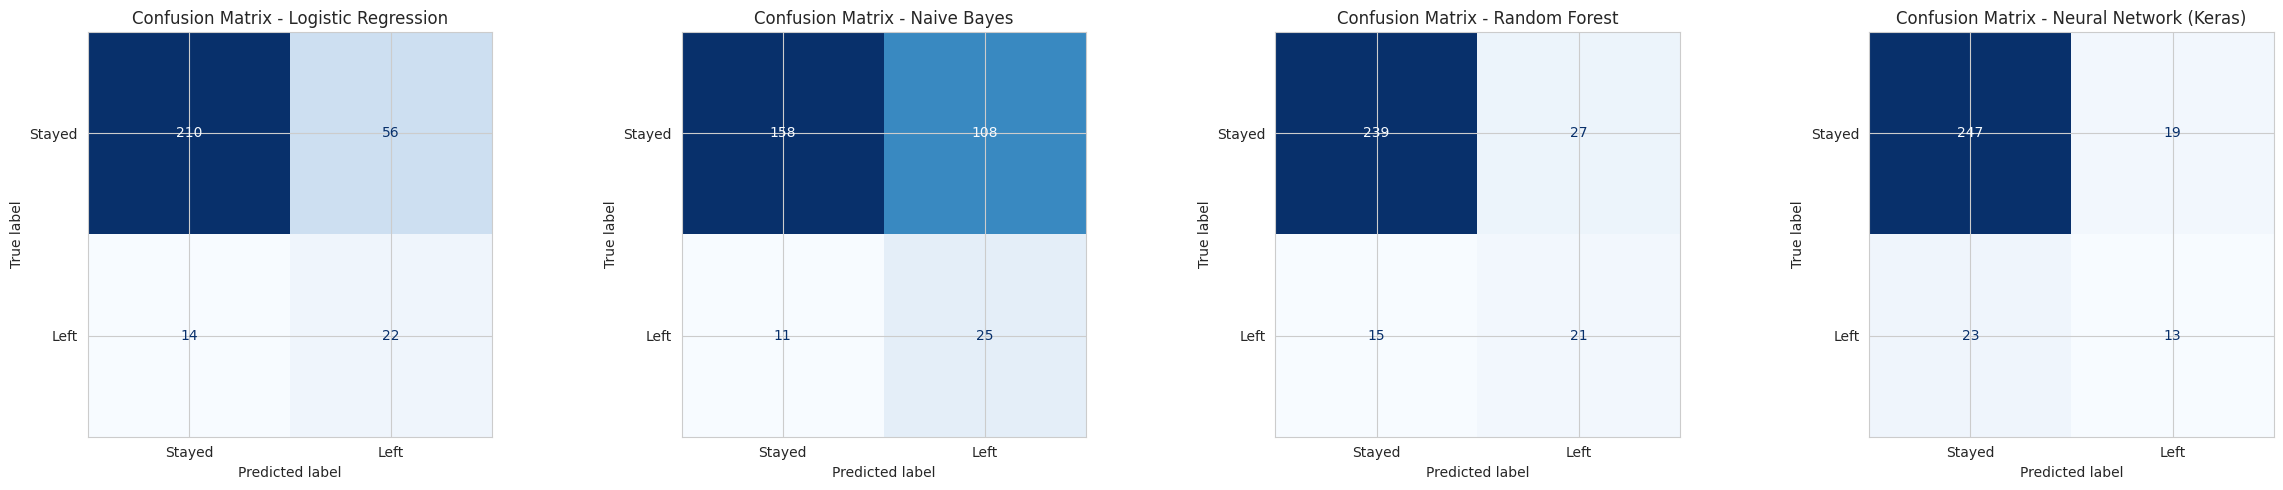

In [59]:
fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 5))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=['Stayed','Left']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix - {name}')
plt.tight_layout()
save_fig(fig, '11_confusion_matrices.png')
plt.show()

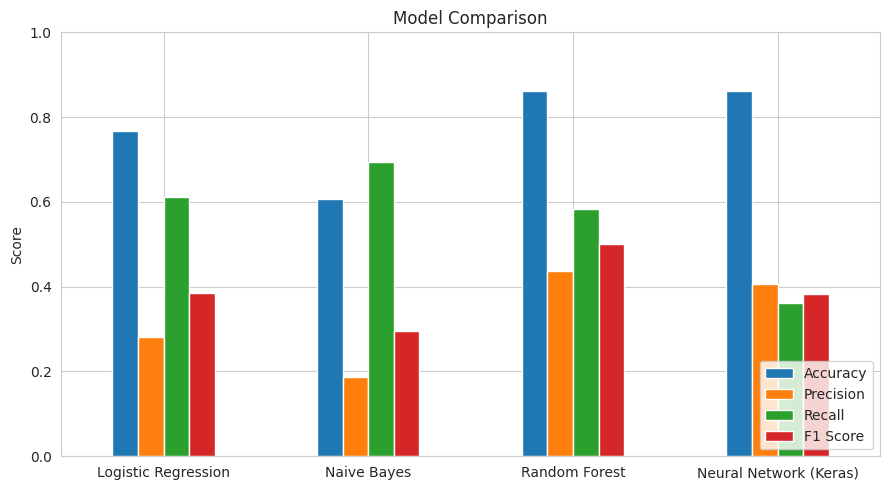

In [60]:
fig = plt.figure(figsize=(9,5))
results_df[['Accuracy','Precision','Recall','F1 Score']].plot(kind='bar', ax=plt.gca())
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
save_fig(fig, '12_model_comparison_bar.png')
plt.show()

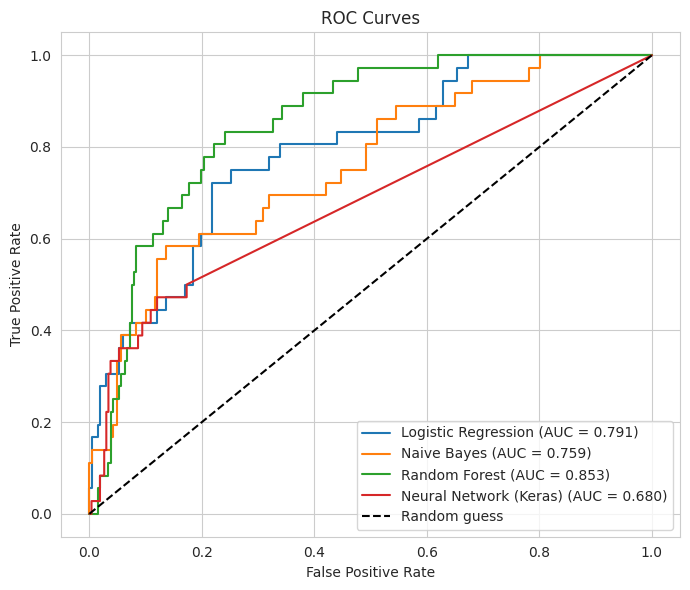

In [61]:
fig = plt.figure(figsize=(7,6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = eval_results[name]['AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
save_fig(fig, '13_roc_curves.png')
plt.show()

### 6.1 Comparing K-Means clusters against the true Attrition label


In [62]:
ari_results = {}
for k, r in kmeans_results.items():
    ari = adjusted_rand_score(y, r['labels'])
    ari_results[k] = ari
    print(f"k={k}: Adjusted Rand Index vs true Attrition label = {ari:.3f}")

ari_df = pd.DataFrame({'k': list(ari_results.keys()), 'Adjusted Rand Index': list(ari_results.values())})
save_table(ari_df, 'kmeans_ari_results.csv')

k=2: Adjusted Rand Index vs true Attrition label = 0.022
k=3: Adjusted Rand Index vs true Attrition label = 0.003


'results/kmeans_ari_results.csv'

### 6.2 Does PCA (dimensionality reduction) help or hurt?



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Full-feature results:
                        Accuracy  Precision  Recall  F1 Score    AUC
Logistic Regression        0.768      0.282   0.611     0.386  0.791
Naive Bayes                0.606      0.188   0.694     0.296  0.759
Random Forest              0.861      0.438   0.583     0.500  0.853
Neural Network (Keras)     0.861      0.406   0.361     0.382  0.680

PCA-reduced-feature results:
                        Accuracy  Precision  Recall  F1 Score    AUC
Logistic Regression        0.788      0.316   0.667     0.429  0.825
Naive Bayes                0.738      0.253   0.611     0.358  0.737
Neural Network (Keras)     0.831      0.273   0.250     0.261  0.674


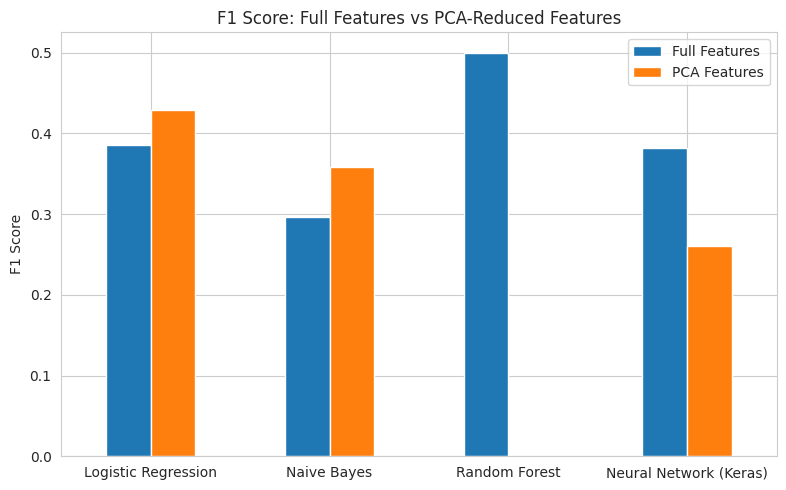

In [63]:
pca_eval_results = {}

pca_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Naive Bayes': GaussianNB(),
}

for name, model_template in pca_models.items():
    model_template.fit(X_train_pca, y_train)
    pred = model_template.predict(X_test_pca)
    proba = model_template.predict_proba(X_test_pca)[:, 1]
    pca_eval_results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred),
        'AUC': roc_auc_score(y_test, proba)
    }

nn_pca_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_pca_model.compile(optimizer=Adam(learning_rate=0.001), loss=BinaryCrossentropy(), metrics=['accuracy'])
nn_pca_model.fit(X_train_pca, y_train, validation_split=0.15, epochs=60, batch_size=32,
                  class_weight=class_weight, verbose=0)

nn_pca_proba = nn_pca_model.predict(X_test_pca, verbose=0).ravel()
nn_pca_pred = (nn_pca_proba >= 0.5).astype(int)
pca_eval_results['Neural Network (Keras)'] = {
    'Accuracy': accuracy_score(y_test, nn_pca_pred),
    'Precision': precision_score(y_test, nn_pca_pred),
    'Recall': recall_score(y_test, nn_pca_pred),
    'F1 Score': f1_score(y_test, nn_pca_pred),
    'AUC': roc_auc_score(y_test, nn_pca_proba)
}

pca_results_df = pd.DataFrame(pca_eval_results).T
print("Full-feature results:")
print(results_df.round(3))
print("\nPCA-reduced-feature results:")
print(pca_results_df.round(3))
save_table(pca_results_df, 'pca_model_comparison_results.csv')

fig = plt.figure(figsize=(8,5))
comparison = pd.concat(
    {'Full Features': results_df['F1 Score'], 'PCA Features': pca_results_df['F1 Score']}, axis=1
)
comparison.plot(kind='bar', ax=plt.gca(), title='F1 Score: Full Features vs PCA-Reduced Features')
plt.ylabel('F1 Score')
plt.xticks(rotation=0)
plt.tight_layout()
save_fig(fig, '14_pca_vs_full_f1_comparison.png')
plt.show()

## 7. Testing on Employees 10% data


In [64]:
test_readable = pd.read_csv('4_test.csv')


cat_cols_test = test_readable.select_dtypes(include='object').columns.tolist()
test_encoded = pd.get_dummies(test_readable, columns=cat_cols_test, drop_first=True)

# 3. ALIGNMENT:
test_encoded = test_encoded.reindex(columns=feature_cols, fill_value=0)

test_scaled = scaler.transform(test_encoded)


pred_table = test_readable.copy()
for name, model in trained.items():
    if name == 'Neural Network (Keras)':
        probs = model.predict(test_scaled, verbose=0).ravel()
    else:
        probs = model.predict_proba(test_scaled)[:, 1]


    if name == 'Random Forest':

        threshold = best_thresh
        preds = (probs >= threshold).astype(int)
    else:
        preds = (probs >= 0.5).astype(int)

    pred_table[f'{name} Prediction'] = np.where(preds == 1, 'Leave', 'Stay')
    pred_table[f'{name} P(Leave)'] = probs.round(3)

pd.set_option('display.max_columns', None)
save_table(pred_table, 'test_csv_predictions.csv')
pred_table

,id,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Logistic Regression Prediction,Logistic Regression P(Leave),Naive Bayes Prediction,Naive Bayes P(Leave),Random Forest Prediction,Random Forest P(Leave),Neural Network (Keras) Prediction,Neural Network (Keras) P(Leave)
0,1309,31,Travel_Rarely,1448,Research & Development,3,3,Medical,1,3,Male,81,2,1,Laboratory Technician,3,Single,3875,21086,7,Y,No,11,3,2,80,0,4,6,3,3,2,1,2,1,Leave,0.808,Leave,0.999,Leave,0.578,Stay,0.000
1,1081,35,Travel_Rarely,885,Research & Development,1,2,Medical,1,2,Male,70,3,1,Laboratory Technician,1,Married,2886,18256,1,Y,No,11,3,2,80,0,5,2,4,5,3,1,3,0,Leave,0.788,Leave,0.999,Leave,0.645,Leave,1.026
2,1583,44,Travel_Rarely,836,Research & Development,29,5,Life Sciences,1,3,Male,100,3,2,Laboratory Technician,4,Married,6272,4605,8,Y,No,18,3,3,80,1,8,3,2,5,4,0,4,0,Stay,0.151,Stay,0.149,Stay,0.087,Stay,0.000
3,711,29,Travel_Rarely,1206,Research & Development,7,3,Medical,1,2,Male,89,3,1,Research Scientist,4,Married,2976,11781,1,Y,No,13,3,2,80,0,1,5,3,1,0,0,0,1,Stay,0.304,Leave,0.994,Leave,0.453,Stay,0.000
4,1388,36,Travel_Rarely,949,Research & Development,1,4,Life Sciences,1,2,Male,57,2,3,Manufacturing Director,3,Married,10008,12023,1,Y,No,14,3,4,80,1,10,3,3,10,9,1,9,0,Stay,0.038,Stay,0.000,Stay,0.066,Stay,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,546,27,Travel_Rarely,482,Sales,2,2,Other,1,2,Male,92,3,2,Sales Executive,4,Married,4249,2690,2,Y,Yes,21,4,1,80,1,5,2,2,3,2,0,2,0,Leave,0.798,Stay,0.001,Stay,0.227,Leave,0.547
164,470,33,Travel_Rarely,1245,Research & Development,10,4,Other,1,1,Male,70,4,2,Research Scientist,3,Married,5775,16143,4,Y,No,19,3,2,80,0,10,5,4,7,7,0,2,0,Stay,0.141,Stay,0.000,Stay,0.266,Stay,0.000
165,1244,40,Travel_Rarely,895,Research & Development,20,3,Medical,1,3,Male,52,2,2,Healthcare Representative,4,Married,7978,21534,1,Y,No,13,3,4,80,0,10,2,3,10,7,0,4,0,Stay,0.141,Stay,0.369,Stay,0.130,Stay,0.000
166,515,25,Travel_Frequently,672,Research & Development,1,3,Medical,1,3,Female,96,2,1,Laboratory Technician,4,Married,3730,25308,1,Y,Yes,21,4,4,80,1,7,3,3,7,3,7,6,0,Leave,0.611,Leave,0.727,Stay,0.166,Stay,0.000


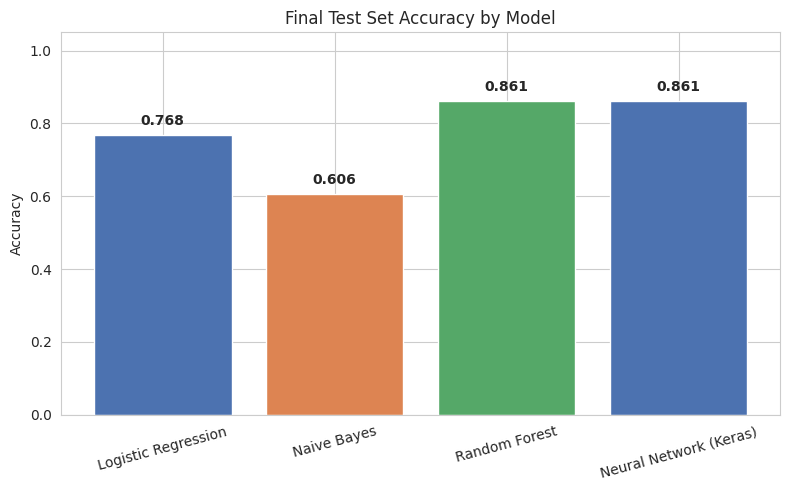

In [65]:

fig = plt.figure(figsize=(8, 5))

accuracies = results_df['Accuracy']
colors = ['#4C72B0', '#DD8452', '#55A868']


bars = plt.bar(accuracies.index, accuracies.values, color=colors[:len(accuracies)])


plt.title('Final Test Set Accuracy by Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
save_fig(fig, '15_final_accuracy_comparison.png')
plt.show()

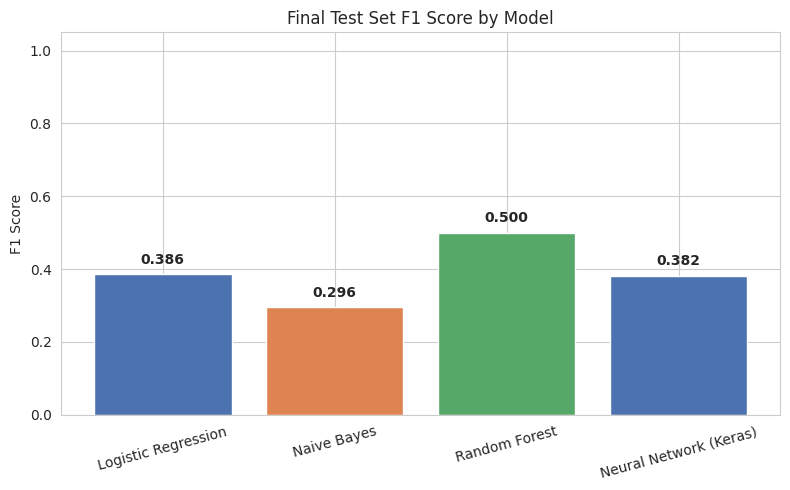

In [67]:
fig = plt.figure(figsize=(8, 5))
f1_scores = results_df['F1 Score']
colors = ['#4C72B0', '#DD8452', '#55A868']


bars = plt.bar(f1_scores.index, f1_scores.values, color=colors[:len(f1_scores)])


plt.title('Final Test Set F1 Score by Model')
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
save_fig(fig, '16_final_f1_comparison.png')
plt.show()

In [ ]:
import shutil
from google.colab import files as colab_files

zip_path = shutil.make_archive('attrition_project_results', 'zip', OUTPUT_DIR)
print(f"Zipped {len(saved_files)} files into {zip_path}")
colab_files.download(zip_path)

**Tip:** if the automatic download prompt is blocked by your browser, open the Colab file browser (folder icon on the left sidebar), find `attrition_project_results.zip` in the file list, and click the three-dot menu → Download.